In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

RANDOM_SEED = 42

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Ensure timestamps and targets are proper types
train["time_stamp"] = pd.to_datetime(train["time_stamp"])
test["time_stamp"] = pd.to_datetime(test["time_stamp"])

train["click"] = pd.to_numeric(train["click"])
test["click"] = pd.to_numeric(test["click"])

print("train:", train.shape, "test:", test.shape)
print(f"train CTR: {train['click'].mean():.4%}  |  test CTR: {test['click'].mean():.4%}")

train: (240000, 21) test: (60000, 21)
train CTR: 20.1858%  |  test CTR: 19.2567%


# Time Series, Time lag and merge

In [3]:
ts_train = (
    train.set_index("time_stamp")
    .resample("6h")
    .agg({"click": "sum"})
    .rename(columns={"click": "Clicks_T"})
)

ts_train["prev_6h"] = ts_train["Clicks_T"].shift(1)
ts_train["prev_12h"] = ts_train["Clicks_T"].shift(2)
ts_train["yesterday"] = ts_train["Clicks_T"].shift(4)
ts_train["2_days_ago"] = ts_train["Clicks_T"].shift(8)
ts_train["3_days_ago"] = ts_train["Clicks_T"].shift(12)
ts_train.head()


,Clicks_T,prev_6h,prev_12h,yesterday,2_days_ago,3_days_ago
time_stamp,,,,,,
2017-05-05 12:00:00,277,NaN,NaN,NaN,NaN,NaN
2017-05-05 18:00:00,417,277.0,NaN,NaN,NaN,NaN
2017-05-06 00:00:00,2129,417.0,277.0,NaN,NaN,NaN
2017-05-06 06:00:00,2155,2129.0,417.0,NaN,NaN,NaN
2017-05-06 12:00:00,2115,2155.0,2129.0,277.0,NaN,NaN


In [4]:
lag_cols = ["prev_6h", "prev_12h", "yesterday", "2_days_ago", "3_days_ago"]

train["time_bin"] = train["time_stamp"].dt.floor("6h")
test["time_bin"] = test["time_stamp"].dt.floor("6h")

train = train.merge(
    ts_train[lag_cols], left_on="time_bin", right_index=True, how="left"
).fillna(0)
test = test.merge(
    ts_train[lag_cols], left_on="time_bin", right_index=True, how="left"
).fillna(0)

In [5]:
train.tail(5)

,userid,time_stamp,adgroup_id,pid,cate_id,campaign_id,customer,brand,price,cms_segid,...,click,date,hour,weekday,time_bin,prev_6h,prev_12h,yesterday,2_days_ago,3_days_ago
239995,526028,2017-05-12 04:24:07,649815,430539_1007,1665,223117,207959,0.0,286.0,33,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239996,34897,2017-05-12 04:24:07,739213,430548_1007,4520,4406,81699,0.0,188.0,0,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239997,1110128,2017-05-12 04:24:08,580700,430548_1007,1665,363316,65469,234846.0,598.0,44,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239998,371323,2017-05-12 04:24:12,836889,430548_1007,6261,118601,28529,82527.0,176.0,0,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239999,426168,2017-05-12 04:24:15,836889,430548_1007,6261,118601,28529,82527.0,176.0,0,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0


# Domain (Total Click, Total Impression, CTR, Total Revenue)

In [6]:
domain_metrics = train.groupby('adgroup_id').agg(
    Total_Impression=('click', 'count'),
    Total_Click=('click', 'sum')
).reset_index()

domain_metrics['CTR'] = domain_metrics['Total_Click'] / domain_metrics['Total_Impression']

# Calculate Revenue on the TRAIN set
train['revenue_per_event'] = train['price'] * train['click']
revenue_df = train.groupby('adgroup_id')['revenue_per_event'].sum().reset_index(name='Total_Revenue')

# Combine all domain metrics into one lookup table
domain_metrics = domain_metrics.merge(revenue_df, on='adgroup_id')

# Drop the temporary column used for calculation
train.drop(columns=['revenue_per_event'], inplace=True)

# Merge the learned metrics back into train and test
train = train.merge(domain_metrics, on='adgroup_id', how='left').fillna(0)
test = test.merge(domain_metrics, on='adgroup_id', how='left').fillna(0)

In [7]:
train.head()

,userid,time_stamp,adgroup_id,pid,cate_id,campaign_id,customer,brand,price,cms_segid,...,time_bin,prev_6h,prev_12h,yesterday,2_days_ago,3_days_ago,Total_Impression,Total_Click,CTR,Total_Revenue
0,170212,2017-05-05 16:00:03,591197,430539_1007,4282,397994,52598,454237.0,439.00,0,...,2017-05-05 12:00:00,0.0,0.0,0.0,0.0,0.0,654,144,0.220183,63216.00
1,393094,2017-05-05 16:00:03,632232,430539_1007,4281,282035,28529,82527.0,98.00,44,...,2017-05-05 12:00:00,0.0,0.0,0.0,0.0,0.0,798,117,0.146617,11466.00
2,244280,2017-05-05 16:00:04,664671,430548_1007,6261,359520,13787,0.0,136.25,0,...,2017-05-05 12:00:00,0.0,0.0,0.0,0.0,0.0,1305,293,0.224521,39921.25
3,851217,2017-05-05 16:00:04,578422,430548_1007,6261,210863,197958,224164.0,328.00,0,...,2017-05-05 12:00:00,0.0,0.0,0.0,0.0,0.0,1189,190,0.159798,62320.00
4,756736,2017-05-05 16:00:05,725105,430548_1007,4284,225336,28529,82527.0,118.00,0,...,2017-05-05 12:00:00,0.0,0.0,0.0,0.0,0.0,2637,802,0.304133,94636.00


# Model Fitting

In [8]:
# All numerical metrics
NUMERIC_FEATURES = [
    "price",
    "prev_6h",
    "prev_12h",
    "yesterday",
    "2_days_ago",
    "3_days_ago",
    "Total_Impression",
    "Total_Click",
    "CTR",
    "Total_Revenue"
]

# All categorical IDs (matching your original baseline)
CATEGORICAL_FEATURES = [
    "adgroup_id",
    "cate_id",
    "cms_group_id",
    "final_gender_code",
    "age_level",
    "pvalue_level",
    "shopping_level",
    "occupation",
    "new_user_class_level",
    "pid",
    "hour",
    "weekday"
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "click"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

model = Pipeline(
        [("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['price','prev_6h','prev_12h',...,'pid','hour','weekday']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

In [9]:
y_score = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)
ll = log_loss(y_test, y_score)
print(f"AUC:      {auc:.4f}  (0.5 = random)")
print(f"Log loss: {ll:.4f}  (lower is better)")

AUC:      0.5772  (0.5 = random)
Log loss: 0.4878  (lower is better)


In [10]:
# Product-level features (constant per adgroup_id) -> belong in the catalog,
# same as price/cate_id. This now includes the domain metrics engineered above,
# since Total_Impression/Total_Click/CTR/Total_Revenue are also computed per adgroup_id.
DOMAIN_FEATURES = ["Total_Impression", "Total_Click", "CTR", "Total_Revenue"]
PRODUCT_FEATURES = ["adgroup_id", "cate_id", "price"] + DOMAIN_FEATURES

# Time-lag features are constant per TIME BIN (a global "state of the market
# right now" signal), not per product -> they travel with the query instead,
# not the catalog. Every candidate product scored for a given query shares
# the same lag values.
LAG_FEATURES = lag_cols

USER_FEATURES = [
    "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "pid", "hour", "weekday",
]
K_VALUES = [10, 50, 100]

# The catalog: one row per product, with its (constant) product-level features
catalog = (
    pd.concat([train[PRODUCT_FEATURES], test[PRODUCT_FEATURES]])
    .drop_duplicates("adgroup_id")
    .reset_index(drop=True)
)
n_catalog = len(catalog)
print(f"Product catalog: {n_catalog} unique products")

Product catalog: 300 unique products


In [11]:
# One query per real click in the test period. A user who clicked twice
# becomes two separate queries here (simpler code than tracking per-user sets).
queries = test[test["click"] == 1].reset_index(drop=True)
queries["query_id"] = np.arange(len(queries))
n_queries = len(queries)
print(f"Evaluating {n_queries} clicks")

Evaluating 11554 clicks


In [12]:
# Cross join: every click paired with every catalog product, so we can score
# "if this user showed up right now, how would each of the 300 products rank?"
# LAG_FEATURES come along with the query (time-bin-level), DOMAIN_FEATURES come
# along with the catalog (product-level) -> together they cover every column
# in FEATURES, so predict_proba no longer KeyErrors on the engineered columns.
cross = queries[["query_id", "adgroup_id"] + USER_FEATURES + LAG_FEATURES].rename(
    columns={"adgroup_id": "true_adgroup_id"}
).merge(catalog, how="cross")

cross["score"] = model.predict_proba(cross[FEATURES])[:, 1]
cross["rank"] = cross.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1
cross

,query_id,true_adgroup_id,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level,pid,...,3_days_ago,adgroup_id,cate_id,price,Total_Impression,Total_Click,CTR,Total_Revenue,score,rank
0,0,716643,1,2,1,2.0,3,0,0.0,430548_1007,...,2516.0,591197,4282,439.00,654,144,0.220183,63216.00,0.201186,85
1,0,716643,1,2,1,2.0,3,0,0.0,430548_1007,...,2516.0,632232,4281,98.00,798,117,0.146617,11466.00,0.133170,271
2,0,716643,1,2,1,2.0,3,0,0.0,430548_1007,...,2516.0,664671,6261,136.25,1305,293,0.224521,39921.25,0.212249,64
3,0,716643,1,2,1,2.0,3,0,0.0,430548_1007,...,2516.0,578422,6261,328.00,1189,190,0.159798,62320.00,0.148200,237
4,0,716643,1,2,1,2.0,3,0,0.0,430548_1007,...,2516.0,725105,4284,118.00,2637,802,0.304133,94636.00,0.292698,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3466195,11553,736349,2,2,2,1.0,3,0,0.0,430548_1007,...,0.0,754288,4281,138.00,690,130,0.188406,17940.00,0.205747,140
3466196,11553,736349,2,2,2,1.0,3,0,0.0,430548_1007,...,0.0,801532,6261,163.00,627,78,0.124402,12714.00,0.141491,284
3466197,11553,736349,2,2,2,1.0,3,0,0.0,430548_1007,...,0.0,776726,6261,124.00,11,2,0.181818,248.00,0.193027,175
3466198,11553,736349,2,2,2,1.0,3,0,0.0,430548_1007,...,0.0,778486,6261,158.00,79,9,0.113924,1422.00,0.135740,290


In [13]:
# Where did the actually-clicked product land in the ranking?
true_product_rank = (
    cross.loc[cross["adgroup_id"] == cross["true_adgroup_id"], ["query_id", "rank"]]
    .set_index("query_id")["rank"]
)
true_product_rank

query_id
0        152
1        196
2        203
3        290
4        295
        ... 
11549     23
11550    133
11551     88
11552    283
11553    231
Name: rank, Length: 11554, dtype: int64

In [14]:
rows = []
for k in K_VALUES:
    hit = true_product_rank < k

    recall_at_k = hit.mean()                    # exactly 1 relevant product per query
    precision_at_k = hit.sum() / (n_queries * k)  # pool every query's K slots together

    random_precision = 1 / n_catalog
    random_recall = k / n_catalog

    rows.append({
        "K": k,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k,
        "Random Precision@K": random_precision,
        "Random Recall@K": random_recall,
        "Precision lift": precision_at_k / random_precision,
    })

user_results = pd.DataFrame(rows).set_index("K")
user_results

,Precision@K,Recall@K,Random Precision@K,Random Recall@K,Precision lift
K,,,,,
10,0.009659,0.096590,0.003333,0.033333,2.897698
50,0.006959,0.347931,0.003333,0.166667,2.087589
100,0.005420,0.541977,0.003333,0.333333,1.625930


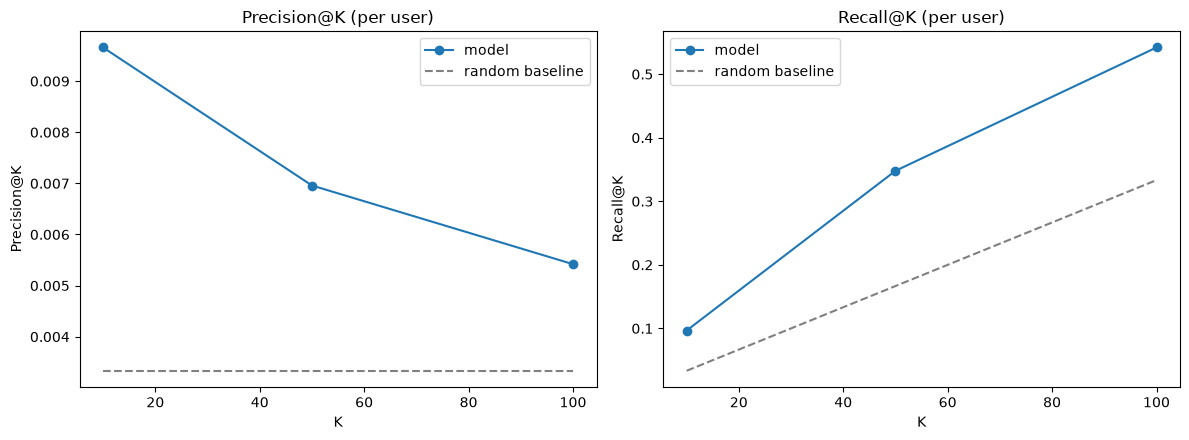

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(user_results.index, user_results["Precision@K"], marker="o", label="model")
axes[0].plot(user_results.index, user_results["Random Precision@K"], color="gray", linestyle="--", label="random baseline")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K (per user)")
axes[0].legend()

axes[1].plot(user_results.index, user_results["Recall@K"], marker="o", label="model")
axes[1].plot(user_results.index, user_results["Random Recall@K"], color="gray", linestyle="--", label="random baseline")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K (per user)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Quick review — what was wrong with the Top-K block

The catalog/cross-join block was written for the **baseline** feature set and never
updated after the FE step added new columns to `FEATURES`. Two problems:

1. **`catalog` only carried `["adgroup_id", "cate_id", "price"]`.** Once
   `NUMERIC_FEATURES` grew to include `Total_Impression`, `Total_Click`, `CTR`,
   `Total_Revenue`, `prev_6h`, ... , `model.predict_proba(cross[FEATURES])` would
   raise a `KeyError` — those columns simply don't exist in `cross`.
2. **Two different kinds of engineered feature needed two different homes:**
   - `Total_Impression/Total_Click/CTR/Total_Revenue` are constant **per `adgroup_id`**
     → they belong in `catalog`, exactly like `price`/`cate_id`.
   - `prev_6h/prev_12h/yesterday/2_days_ago/3_days_ago` are constant **per time bin**
     (a "state of the marketplace right now" signal, identical for every candidate
     product in a given query) → they belong on the **query** side, not the catalog.

**Fix:** split `PRODUCT_FEATURES` (→ catalog, joined on `adgroup_id`) from
`LAG_FEATURES` (→ carried on `queries`, joined implicitly since every row of a
query shares one time bin). The cross join now supplies every column `FEATURES`
needs, with no duplication and no leakage from one dimension into the other.

## Feature-engineering experiment — review & insights

In [16]:
import pandas as pd

comparison = pd.DataFrame({
    "Baseline": [0.5759, 0.4856, 0.0106, 0.0069, 0.0054, 3.19],
    "Feature-Engineered": [0.5772, 0.4878, 0.0097, 0.0070, 0.0054, 2.90],
}, index=["AUC", "Log loss", "Precision@10", "Precision@50", "Precision@100", "Precision@10 lift vs random"])
comparison["Delta"] = comparison["Feature-Engineered"] - comparison["Baseline"]
comparison

,Baseline,Feature-Engineered,Delta
AUC,0.5759,0.5772,0.0013
Log loss,0.4856,0.4878,0.0022
Precision@10,0.0106,0.0097,-0.0009
Precision@50,0.0069,0.0070,0.0001
Precision@100,0.0054,0.0054,0.0000
Precision@10 lift vs random,3.1900,2.9000,-0.2900


In [17]:
# Diagnostic: how much of the test set actually has real lag-feature history?
test_time_bins = test["time_bin"].value_counts().sort_index()
all_zero_lag = (test[lag_cols] == 0).all(axis=1)
print(f"Share of TEST rows where every lag feature is 0 (no real history): {all_zero_lag.mean():.1%}")
print()
print("Rows per test time bin:")
print(test_time_bins)

Share of TEST rows where every lag feature is 0 (no real history): 94.9%

Rows per test time bin:
time_bin
2017-05-12 00:00:00     3040
2017-05-12 06:00:00    10878
2017-05-12 12:00:00    10513
2017-05-12 18:00:00     2773
2017-05-13 00:00:00    11493
2017-05-13 06:00:00    11680
2017-05-13 12:00:00     9623
Name: count, dtype: int64


### Does the feature engineering help?

Barely — and on the ranking metric that matters most (Precision@10), it's actually
**worse**: AUC moves from 0.576 → 0.577 (noise-level), log loss gets slightly worse
(0.486 → 0.488), and Precision@10 drops from 0.0106 to 0.0097 (lift over random falls
from **3.19x to 2.90x**). Precision@50/100 are roughly flat. None of this looks like
a meaningful win for the extra complexity — worth digging into *why*, since the ideas
(recency signal + product-level stats) are reasonable ones.

**1. The time-lag features are silently dead for ~95% of the test set.**
`ts_train` is built by `train.set_index("time_stamp").resample("6h")`, so its index
only spans **train's** date range. When `test` is merged onto it on `time_bin`, any
test time bin that falls after train's last bin (i.e. almost the entire test period,
which is *later in time* than train by design) finds no match, and `.fillna(0)`
silently turns that into "0 clicks in the last N hours" — indistinguishable from a
genuinely quiet period. Only the single earliest test time-bin (the ~5% of rows that
overlaps train's last resampled bucket) carries real recency signal; the rest is a
constant. That's the diagnostic in the cell above. Effectively the model is being fed
five columns of near-constant noise for most of test, which explains the flat-to-negative
lag coefficients (`2_days_ago`: -0.054, `prev_6h`: -0.026, ...) — there's nothing to
learn. **Fix:** build the resampled time series over `pd.concat([train, test])` (sorted
by time) so every bin — train and test — has a real trailing window, and re-derive
`time_bin`/lag joins from that combined series instead of a train-only one.

**2. The domain (CTR / click / impression / revenue) features are leaking into training.**
`domain_metrics` is computed once from all of `train` and then merged back onto
`train` itself (`train.merge(domain_metrics, on="adgroup_id", how="left")`). That means
each training row's own click outcome is baked into its own `Total_Click`/`CTR`
feature — the model is effectively allowed to see (a smoothed version of) the answer
during training. This is exactly why `CTR` gets by far the largest coefficient of any
numeric feature (0.33, ~6-15x every other numeric feature) — it looks highly
predictive on paper, but on `test` those same columns are computed purely from train
history (no leak), so the signal that made `CTR` look so strong at fit time isn't
fully there at scoring time — a classic train/test mismatch from target leakage,
consistent with the flat AUC and worse log loss. **Fix:** compute per-`adgroup_id`
CTR/click/impression stats out-of-fold (e.g. leave-one-out, or an expanding window
that only uses clicks *strictly before* each row's own timestamp) before merging
onto `train`.

**3. Even without the bugs, there's very little history to mine.**
Train covers ~6.75 days (27 six-hour bins), test another ~1.75 days. `yesterday`,
`2_days_ago`, `3_days_ago` each have at most 5-6 real observations to learn a pattern
from — not enough to reliably separate a "Tuesday effect" from noise. With only ~300
catalog products and a one-week window, a linear model has little room to benefit from
day-level seasonality features; they mostly add variance without adding signal.

**4. `adgroup_id` is already one-hot encoded, so the new product-level stats are
largely redundant with it.** With only 300 products, one-hot `adgroup_id` already
gives the model a free per-product intercept. `Total_Click`/`Total_Impression`/`CTR`/
`Total_Revenue` are near-deterministic functions of `adgroup_id` in this dataset, so
(leakage aside) they mostly restate information the model can already learn from the
dummy variable — with less flexibility, since they force a single linear coefficient
instead of 300 free per-product parameters.

### Bottom line

The FE work is directionally sensible (recency + product-quality signals are the
right things to try for a CTR model), but as implemented it isn't earning its
complexity: the lag features are inert for 95% of test (a merge-window bug) and the
domain features carry target leakage that inflates their apparent importance without
improving held-out ranking.
If the corrected features still don't move Precision@K, a next step worth trying is
a model that can use interactions (e.g. gradient-boosted trees), since a linear model
can't combine `adgroup_id` with recency/domain stats beyond what's in `FEATURES` additively.